In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

In [2]:
# path1 = 'C:\\Users\\hp\\Desktop\\image_00431.png'
path1 = 'C:\\Users\\hp\\Desktop\\2.png'
# image = cv2.imread('C:\\Users\\hp\\Desktop\\1.jpg')
# path1 = 'E:\\temp\\gj\\circle_light\\3\\1.bmp'
image = cv2.imread(path1)
print(image.shape)

(818, 1876, 3)


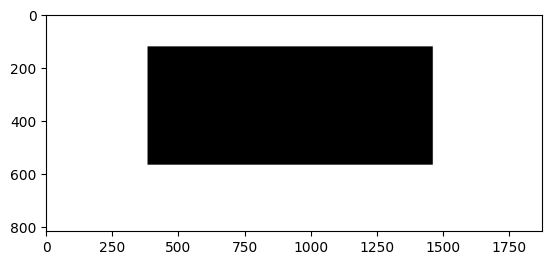

In [3]:
plt.imshow(image)
plt.show()

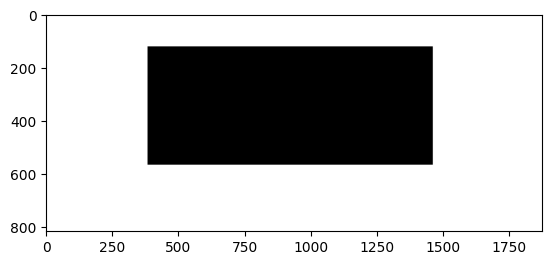

In [4]:
img1 = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #灰度化
plt.imshow(img1, cmap='gray')
plt.show()

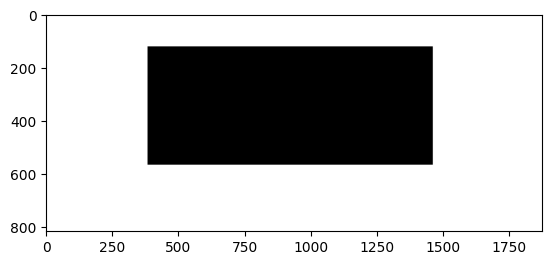

In [5]:
th = 200
retval, img_binary = cv2.threshold(img1, th, 255, cv2.THRESH_BINARY) #
plt.imshow(img_binary, cmap='gray')
plt.show()

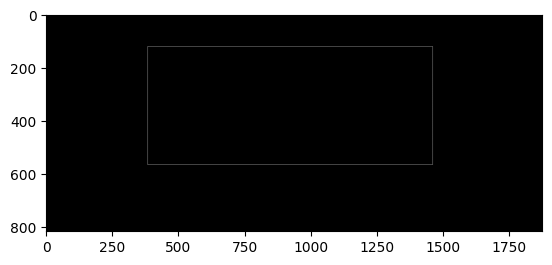

In [6]:
img2 = cv2.Laplacian(img_binary, -1)
plt.imshow(img2, cmap='gray')
plt.show()

In [7]:
#找轮廓并发现最大轮廓
index_tune = 0
contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# contours, hierarchy	= cv2.findContours(img2, cv2.RETR_FLOODFILL, cv2.CHAIN_APPROX_NONE)

# contours = np.array(contours, dtype=object) #轮廓的长度不一样，无法表示为一个固定大小的numpy数组
contours_size = np.array([len(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[index_tune] #取一个轮廓，按t增加索引

In [8]:
print(contours_size)
print(idx)

[1124]
0


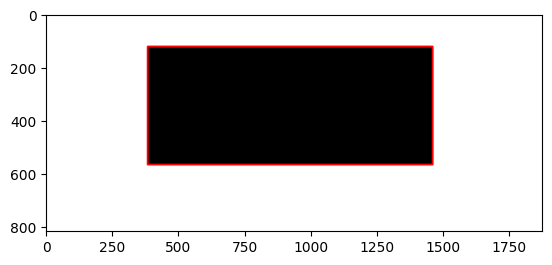

In [8]:
src_img = image.copy()
cv2.drawContours(src_img, contours, idx, (255,0,0), thickness=5) #画原轮廓，绿色
plt.imshow(src_img)
plt.show()

In [10]:
contour = contours[idx]
print(contour.shape)

(1124, 1, 2)


0.0
(32, 1, 2)


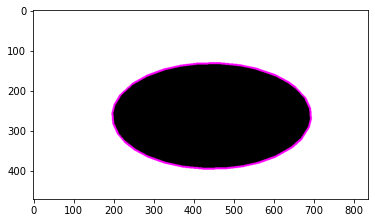

In [11]:
#多边形拟合
src_img = image.copy()
t1 = time.time()
poly = cv2.approxPolyDP(contour, 2, True) #多边形拟合
print(time.time()-t1)
print(poly.shape)
cv2.drawContours(src_img, [poly], 0, (255,0,255), thickness=3) #画原轮廓
plt.imshow(src_img)
plt.show()

0.00046563148498535156
(32, 1, 2)


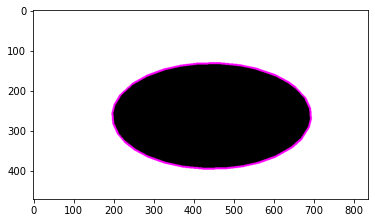

In [12]:
# 轮廓凸包
src_img = image.copy()
t1 = time.time()
hull = cv2.convexHull(poly) #轮廓凸包
print(time.time()-t1)
print(hull.shape)
cv2.drawContours(src_img, [hull], 0, (255,0,255), thickness=3) #画原轮廓
plt.imshow(src_img)
plt.show()

In [13]:
from myContoursAnalyze import ContoursCommonHelper

耗时为： 0.003599882125854492


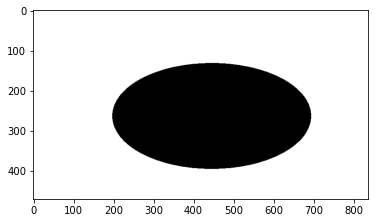

In [14]:
# pl = find_coutour_corner(hull, deg_th_up=160, deg_th_down= 40, dis_th= 20)
pl = ContoursCommonHelper.find_coutour_corner(poly, deg_th_up=140, deg_th_down= 40, dis_th= 20)

src_img = image.copy()
for i in range(0, len(pl)):
    cv2.circle(src_img, (int(pl[i][0]), int(pl[i][1])), 8, (255,0,0), 2)
plt.imshow(src_img)
plt.show()

[[197.44402 131.625  ]
 [694.58594 131.63458]
 [694.5808  395.46777]
 [197.4389  395.4582 ]]


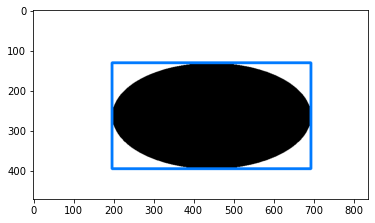

In [15]:
#椭圆拟合
src_img = image.copy()
retval_rect = cv2.fitEllipse(poly)
ContoursCommonHelper.drawRotateRectCV(src_img, retval_rect)
plt.imshow(src_img)
plt.show()
# print(cv2.fitEllipse(poly))

In [ ]:
#轮廓矩探索
src_img = image.copy()
ins_moments = cv2.moments(poly)
print(ins_moments)

#获取重心
x_ = ins_moments['m10']/ ins_moments['m00']
y_ = ins_moments['m01']/ ins_moments['m00']
cout_barycenter = [x_, y_]
print('轮廓重心为: ', cout_barycenter)
cv2.circle(src_img, (int(x_), int(y_)), 8, (255,0,122), 5)
plt.imshow(src_img)
plt.show()